# NGC4064 and NGC4396 VRI Masking Check

This notebook checks whether the local VRI masking products line up with the finite `HA6562_FLUX_CORR` footprint in the older `extended` gas-bin FITS products.

Layers in the inspection plots:

- Bottom image: local `*_combined_VRI.png` from `/Users/Igniz/Desktop/ICRAR/v3tk_masking_VRI`.
- Yellow contour: finite pixels in `HA6562_FLUX_CORR` from `/Users/Igniz/Desktop/ICRAR/extended/*_gas_BIN_maps_extended.fits`.
- Green contour: foreground-star outline extracted from the local `*_combined_VRI_mask.png` diagnostic overlay.
- Orange contour: brown background-object outline extracted from the local `*_combined_VRI_mask.png` diagnostic overlay, recolored orange here for visibility.

The local `*_mask.fits` files contain only a binary `MASK` extension, so the foreground/background split is not stored as separate FITS planes. The color-separated contours below recover that split from the existing diagnostic overlay image. Existing yellow FoV and blue target-isophote diagnostic lines in the overlay PNG are ignored here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from matplotlib.lines import Line2D
from PIL import Image

ROOT = Path('/Users/Igniz/Desktop/ICRAR/v3tk_masking_VRI')
EXTENDED = Path('/Users/Igniz/Desktop/ICRAR/extended')

GALAXIES = {
    'NGC4064': {
        'image': ROOT / 'NGC4064_combined_VRI.png',
        'overlay': ROOT / 'NGC4064_combined_VRI_mask.png',
        'mask': ROOT / 'NGC4064_mask.fits',
        'ha': EXTENDED / 'NGC4064_gas_BIN_maps_extended.fits',
    },
    'NGC4396': {
        'image': ROOT / 'NGC4396_combined_VRI.png',
        'overlay': ROOT / 'NGC4396_combined_VRI_mask.png',
        'mask': ROOT / 'NGC4396_mask.fits',
        'ha': EXTENDED / 'NGC4396_gas_BIN_maps_extended.fits',
    },
}

In [2]:
def read_rgb(path):
    return np.asarray(Image.open(path).convert('RGB'))


def overlay_color_masks(base_rgb, overlay_rgb, diff_threshold=45):
    """Recover diagnostic foreground/background outlines from the overlay PNG colors."""
    diff = np.abs(overlay_rgb.astype(np.int16) - base_rgb.astype(np.int16)).sum(axis=2)
    changed = diff > diff_threshold

    r = overlay_rgb[..., 0].astype(float)
    g = overlay_rgb[..., 1].astype(float)
    b = overlay_rgb[..., 2].astype(float)

    foreground_green = changed & (g > 100) & (g > 1.15 * r) & (g > 1.15 * b)
    # The existing diagnostic PNG also contains yellow FoV and blue target-isophote lines.
    # Keep only true brown background-object outlines, then recolor them orange in the plots.
    background_orange = changed & (r > 90) & (g < 105) & (b < 105) & (r > 1.45 * g) & (r > 1.45 * b)
    return np.flipud(foreground_green), np.flipud(background_orange)


def read_products(galaxy, paths):
    image = read_rgb(paths['image'])
    overlay = read_rgb(paths['overlay'])

    with fits.open(paths['ha'], memmap=True) as hdul:
        ha = np.asarray(hdul['HA6562_FLUX_CORR'].data, dtype=float)
        ha_unit = hdul['HA6562_FLUX_CORR'].header.get('BUNIT', '')

    with fits.open(paths['mask'], memmap=True) as hdul:
        binary_mask = np.asarray(hdul['MASK'].data) > 0

    fg_green, bg_orange = overlay_color_masks(image, overlay)
    finite_ha = np.isfinite(ha)

    expected_shape = image.shape[:2]
    for label, arr in [('HA6562_FLUX_CORR', ha), ('MASK', binary_mask), ('foreground overlay', fg_green), ('background overlay', bg_orange)]:
        if arr.shape != expected_shape:
            raise ValueError(f'{galaxy}: {label} shape {arr.shape} does not match image shape {expected_shape}')

    return {
        'image': image,
        'finite_ha': finite_ha,
        'binary_mask': binary_mask,
        'fg_green': fg_green,
        'bg_orange': bg_orange,
        'ha_unit': ha_unit,
    }


def summarize(galaxy, data):
    finite = data['finite_ha']
    binary = data['binary_mask']
    fg = data['fg_green']
    bg = data['bg_orange']
    return {
        'galaxy': galaxy,
        'shape': finite.shape,
        'finite_Ha_pixels': int(finite.sum()),
        'binary_mask_pixels': int(binary.sum()),
        'mask_inside_finite_Ha': int((binary & finite).sum()),
        'foreground_outline_pixels': int(fg.sum()),
        'background_outline_pixels': int(bg.sum()),
        'Ha_BUNIT': data['ha_unit'],
    }

In [3]:
products = {gal: read_products(gal, paths) for gal, paths in GALAXIES.items()}
summaries = [summarize(gal, data) for gal, data in products.items()]
summaries

[{'galaxy': 'NGC4064',
  'shape': (665, 566),
  'finite_Ha_pixels': 155525,
  'binary_mask_pixels': 493,
  'mask_inside_finite_Ha': 0,
  'foreground_outline_pixels': 159,
  'background_outline_pixels': 0,
  'Ha_BUNIT': '1e-20 erg s-1 cm-2'},
 {'galaxy': 'NGC4396',
  'shape': (755, 883),
  'finite_Ha_pixels': 158915,
  'binary_mask_pixels': 867,
  'mask_inside_finite_Ha': 681,
  'foreground_outline_pixels': 225,
  'background_outline_pixels': 140,
  'Ha_BUNIT': '1e-20 erg s-1 cm-2'}]

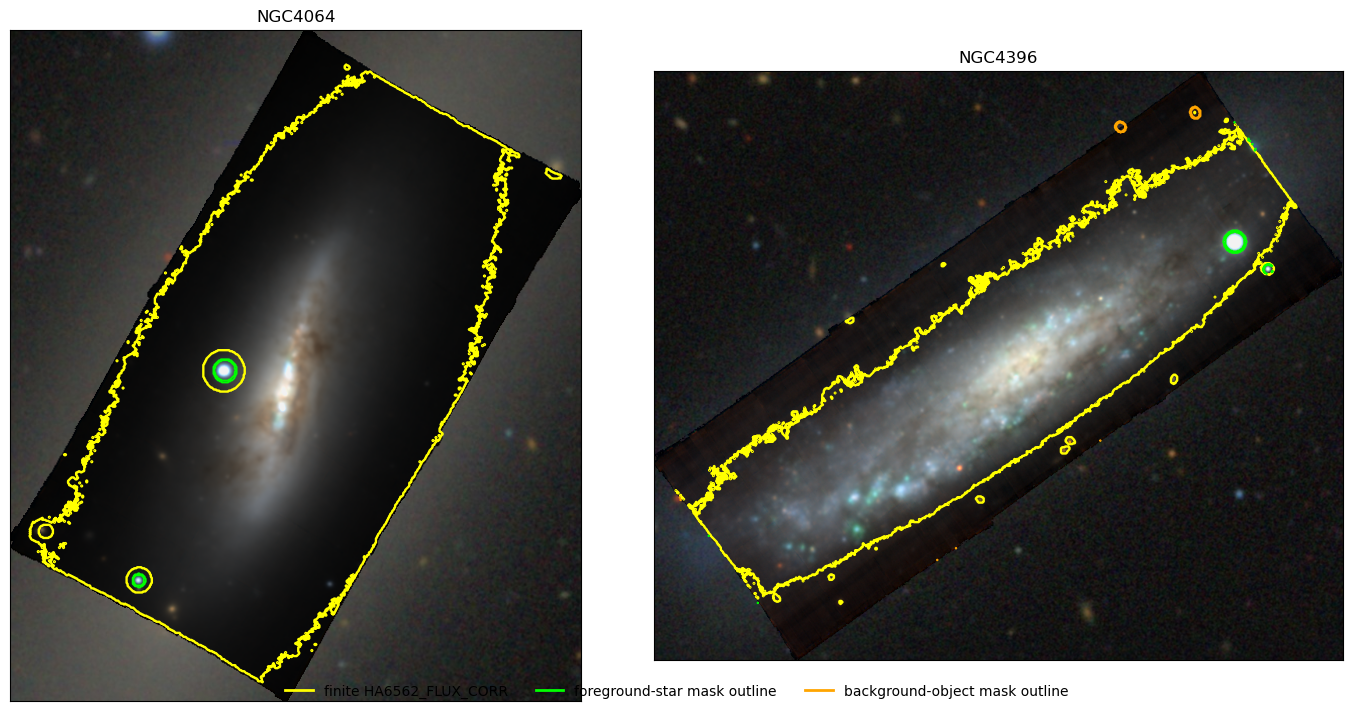

In [4]:
legend_handles = [
    Line2D([0], [0], color='yellow', lw=2.0, label='finite HA6562_FLUX_CORR'),
    Line2D([0], [0], color='lime', lw=2.0, label='foreground-star mask outline'),
    Line2D([0], [0], color='orange', lw=2.0, label='background-object mask outline'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, (galaxy, data) in zip(axes, products.items()):
    ax.imshow(data['image'], origin='upper')
    ax.contour(data['finite_ha'].astype(float), levels=[0.5], colors='yellow', linewidths=1.7, origin='upper')
    if data['fg_green'].any():
        ax.contour(data['fg_green'].astype(float), levels=[0.5], colors='lime', linewidths=1.3, origin='upper')
    if data['bg_orange'].any():
        ax.contour(data['bg_orange'].astype(float), levels=[0.5], colors='orange', linewidths=1.3, origin='upper')
    ax.set_title(galaxy)
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=False)
plt.show()

## Single-galaxy views

The cells below repeat the same overlay one galaxy at a time so the contours can be inspected at a larger size.

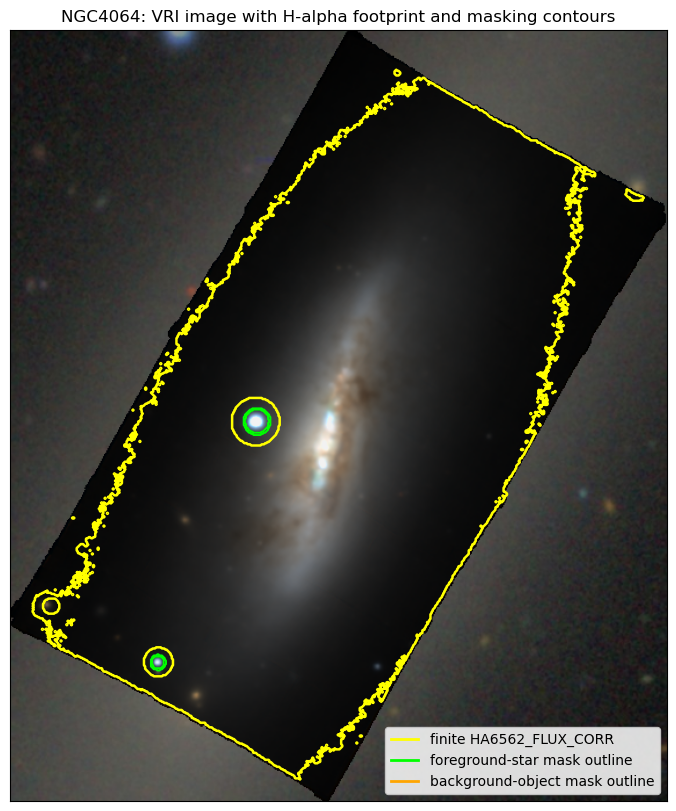

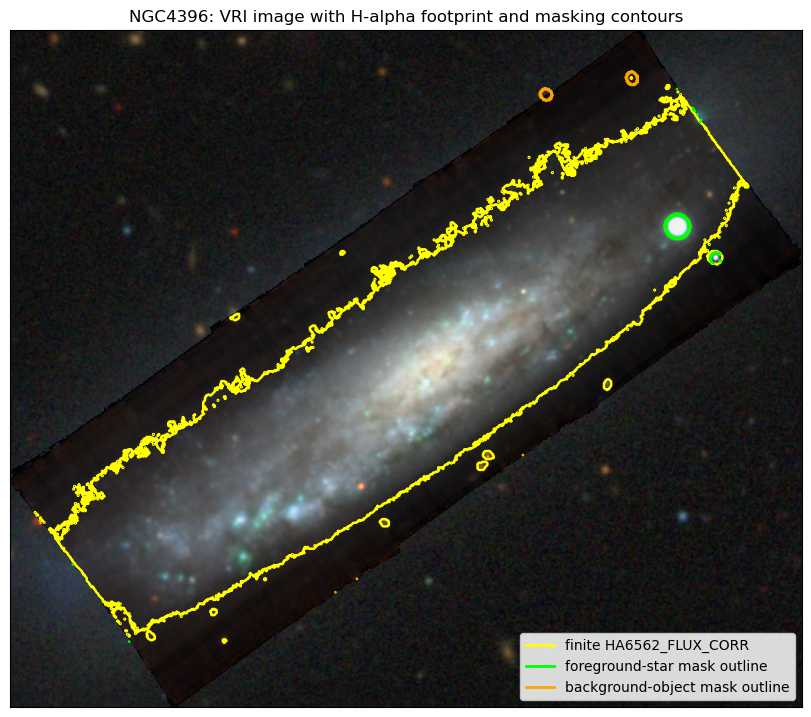

In [5]:
for galaxy, data in products.items():
    fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
    ax.imshow(data['image'], origin='upper')
    ax.contour(data['finite_ha'].astype(float), levels=[0.5], colors='yellow', linewidths=1.8, origin='upper')
    if data['fg_green'].any():
        ax.contour(data['fg_green'].astype(float), levels=[0.5], colors='lime', linewidths=1.4, origin='upper')
    if data['bg_orange'].any():
        ax.contour(data['bg_orange'].astype(float), levels=[0.5], colors='orange', linewidths=1.4, origin='upper')
    ax.set_title(f'{galaxy}: VRI image with H-alpha footprint and masking contours')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(handles=legend_handles, loc='lower right', framealpha=0.85)
    plt.show()